In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1)load dataset

file_path = "heart.csv"
df = pd.read_csv(file_path)

print("original dataset:", df.shape)
print("first 5 rows:")
print(df.head())
print(df.dtypes)

original dataset: (1025, 14)
first 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0      1.0      168      0      1.0      2   
1   53    1   0       140   203    1      0.0      155      1      3.1      0   
2   70    1   0       145   174    0      1.0      125      1      2.6      0   
3   61    1   0       148   203    0      1.0      161      0      0.0      2   
4   62    0   0       138   294    1      1.0      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg     float64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [2]:
# 2)handle missing values

df.replace(["?", "NA", "N/A", "", " "], np.nan, inplace=True)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

cat_cols = df.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("missing values:")
print(df.isnull().sum())

missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


/tmp/ipykernel_3794/3654646051.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")
/tmp/ipykernel_3794/3654646051.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [3]:
# 3)encode categorical variables

possible_cat = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

existing_cat = [col for col in possible_cat if col in df.columns]

existing_cat += list(cat_cols)
existing_cat = list(set(existing_cat))

target_col = "target" if "target" in df.columns else None


df_encoded = pd.get_dummies(df, columns=existing_cat, drop_first=True)

In [4]:
# 4)normalize numerical features

if target_col and target_col in df_encoded.columns:
    feature_cols = [col for col in df_encoded.columns if col != target_col]
else:
    feature_cols = df_encoded.columns.tolist()

scaler = MinMaxScaler()
df_encoded[feature_cols] = scaler.fit_transform(df_encoded[feature_cols])


In [5]:
# 5)feature selection using correlation

if target_col and target_col in df_encoded.columns:
    correlation_with_target = df_encoded.corr()[target_col].sort_values(ascending=False)

    print("correlation with target:")
    print(correlation_with_target)


    important_features = correlation_with_target.drop(target_col, errors="ignore")

    print("top important features:")
    print(important_features.head(10))
else:
    print("no target column found")


correlation with target:
target         1.000000
thal_2         0.519543
thalach        0.422895
slope_2        0.389140
cp_2           0.319504
cp_1           0.255288
restecg_1.0    0.178573
ca_4           0.085639
cp_3           0.085054
fbs_1         -0.041164
restecg_2.0   -0.076357
thal_1        -0.095541
chol          -0.099966
trestbps      -0.138772
ca_3          -0.205720
age           -0.229324
ca_1          -0.235299
ca_2          -0.276566
sex_1         -0.279501
slope_1       -0.349417
oldpeak       -0.437826
exang_1       -0.438029
thal_3        -0.479709
Name: target, dtype: float64
top important features:
thal_2         0.519543
thalach        0.422895
slope_2        0.389140
cp_2           0.319504
cp_1           0.255288
restecg_1.0    0.178573
ca_4           0.085639
cp_3           0.085054
fbs_1         -0.041164
restecg_2.0   -0.076357
Name: target, dtype: float64


In [6]:
# 6)save cleaned data

output_file = "cleaned_data.csv"
df_encoded.to_csv(output_file, index=False)

print("cleaned dataset:", output_file)
print("cleaned dataset:", df_encoded.shape)


cleaned dataset: cleaned_data.csv
cleaned dataset: (1025, 23)


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dff=pd.read_csv("cleaned_data.csv")

print(dff.describe())

               age     trestbps         chol      thalach      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.529878     0.354827     0.273973     0.596291     0.172825   
std       0.189006     0.165252     0.117791     0.175616     0.189503   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.395833     0.245283     0.194064     0.465649     0.000000   
50%       0.562500     0.339623     0.260274     0.618321     0.129032   
75%       0.666667     0.433962     0.340183     0.725191     0.290323   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

            target         ca_1         ca_2         ca_3         ca_4  ...  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000  ...   
mean      0.513171     0.220488     0.130732     0.067317     0.017561  ...   
std       0.500070     0.414778     0.337271     0.250693     0.131413  ...   
min       0.00000

In [8]:
numerical_cols = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak']

print("Statistical Summary:")
print(dff[numerical_cols].describe())

Statistical Summary:
               age         chol     trestbps      thalach      oldpeak
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000
mean      0.529878     0.273973     0.354827     0.596291     0.172825
std       0.189006     0.117791     0.165252     0.175616     0.189503
min       0.000000     0.000000     0.000000     0.000000     0.000000
25%       0.395833     0.194064     0.245283     0.465649     0.000000
50%       0.562500     0.260274     0.339623     0.618321     0.129032
75%       0.666667     0.340183     0.433962     0.725191     0.290323
max       1.000000     1.000000     1.000000     1.000000     1.000000


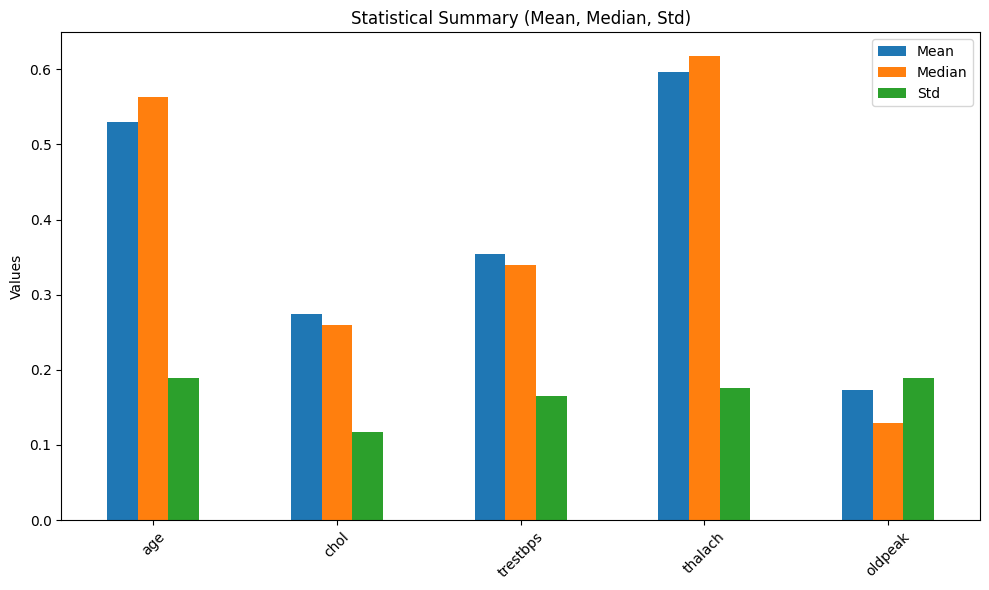

In [9]:
numerical_cols = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak']

summary = dff[numerical_cols].describe().T
summary_plot = summary[['mean', '50%', 'std']]
summary_plot.columns = ['Mean', 'Median', 'Std']
summary_plot.plot(kind='bar', figsize=(10,6))

plt.title("Statistical Summary (Mean, Median, Std)")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

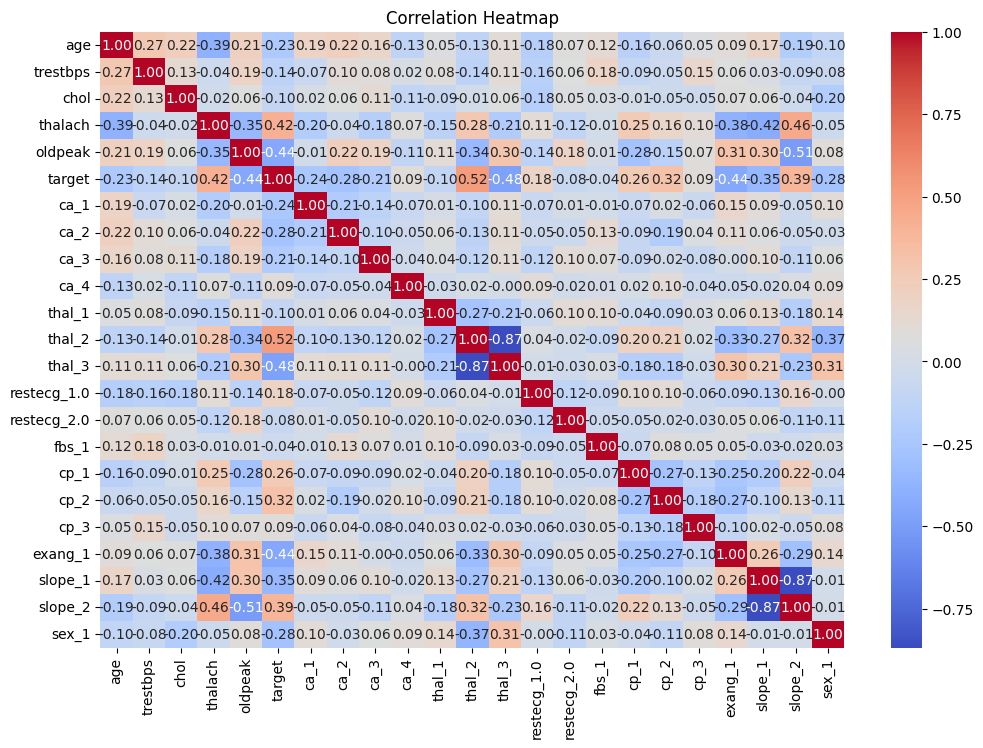

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [10]:
corr = dff.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(8,6))

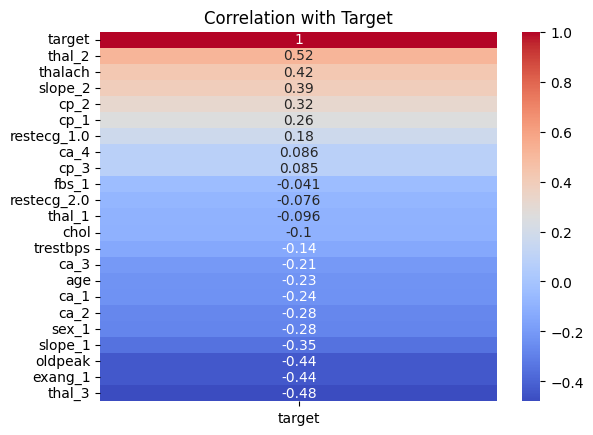

In [11]:
sns.heatmap(dff.corr()[['target']].sort_values(by='target', ascending=False),
            annot=True, cmap="coolwarm")

plt.title("Correlation with Target")
plt.show()

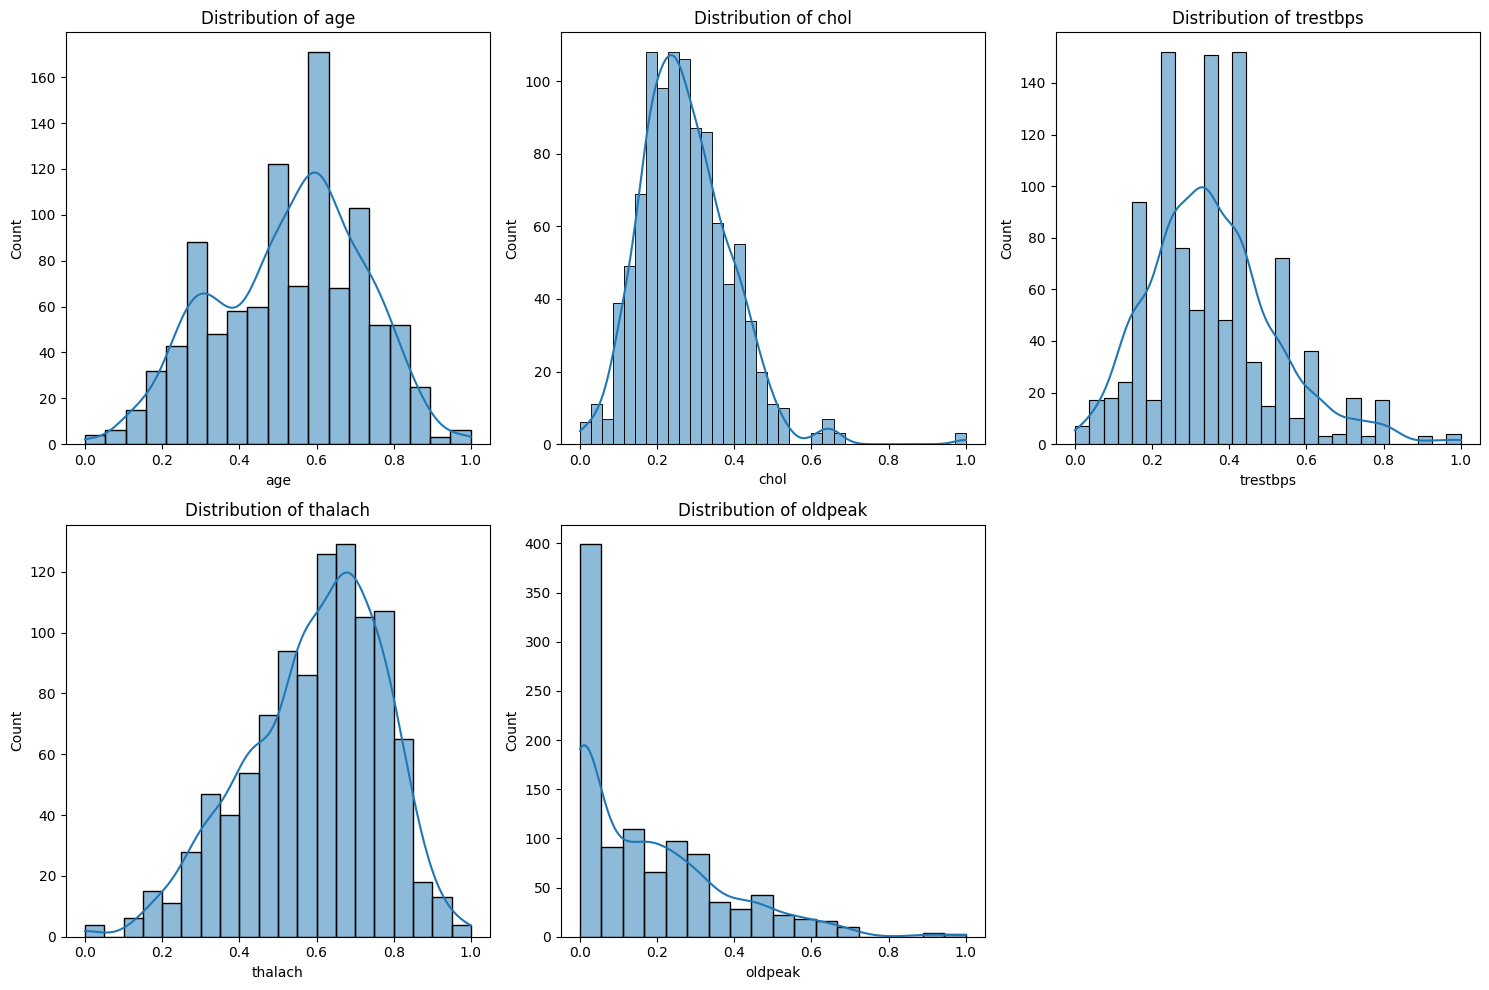

In [12]:
numerical_cols = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak']


plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(dff[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

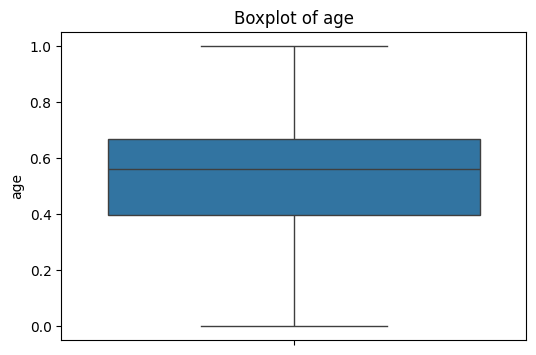

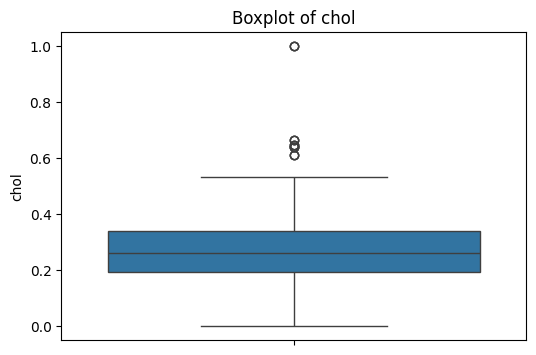

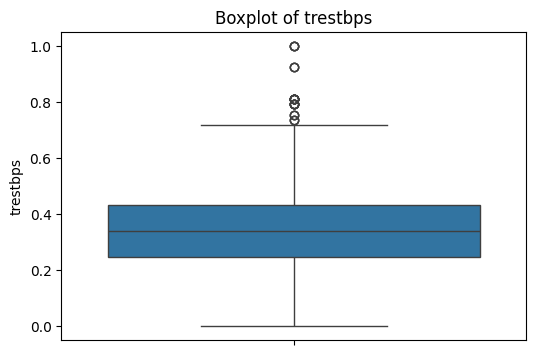

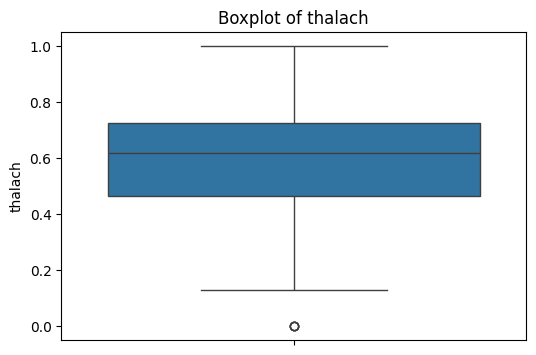

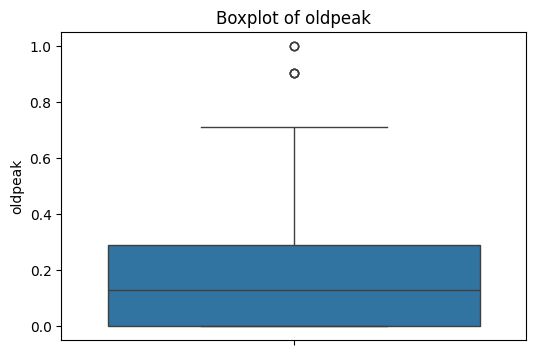

In [13]:
columns = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak']

for col in columns:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(y=dff[col])
        plt.title(f"Boxplot of {col}")
        plt.show()
Q1 = df['thalach'].quantile(0.25)
Q3 = df['thalach'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = dff[(dff['thalach'] >= lower_bound) & (dff['thalach'] <= upper_bound)]

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

X = dff.drop('target', axis=1)
y = dff['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Hyperparameter Tuning
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best model after tuning
model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Train best model
model.fit(X_train, y_train)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2}
Best Cross-Validation Score: 0.9829268292682926


DecisionTreeClassifier(max_depth=10, random_state=42)

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X = dff.drop('target', axis=1)
y = dff['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [16]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)


        Feature  Importance
10       thal_2    0.296789
0           age    0.162718
4       oldpeak    0.138698
1      trestbps    0.100042
3       thalach    0.074805
2          chol    0.069534
7          ca_3    0.035192
21        sex_1    0.034930
17         cp_3    0.028111
5          ca_1    0.023943
19      slope_1    0.010184
20      slope_2    0.007921
9        thal_1    0.007588
16         cp_2    0.005725
15         cp_1    0.003819
13  restecg_2.0    0.000000
11       thal_3    0.000000
8          ca_4    0.000000
6          ca_2    0.000000
12  restecg_1.0    0.000000
14        fbs_1    0.000000
18      exang_1    0.000000


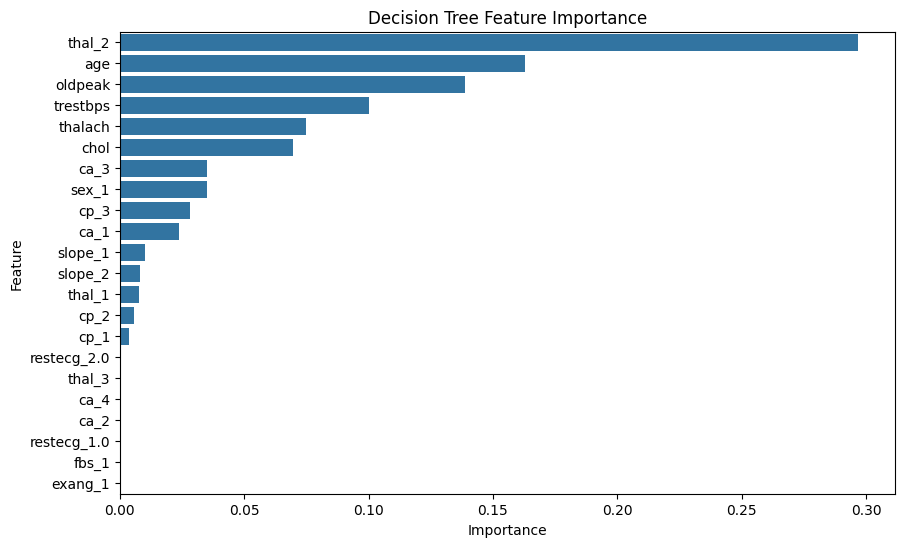

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)

plt.title("Decision Tree Feature Importance")
plt.show()

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Decision Tree Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Decision Tree Performance:
Accuracy: 0.9707317073170731
Precision: 1.0
Recall: 0.941747572815534
F1 Score: 0.97


In [19]:
# Save Model
import joblib
joblib.dump(model, "decision_tree_model.pkl")

print("Model saved successfully")

Model saved successfully


In [20]:
pip install git+https://github.com/nilp0inter/experta.git

  Cloning https://github.com/nilp0inter/experta.git to /tmp/pip-req-build-fgyqbju2
  Running command git clone --filter=blob:none --quiet https://github.com/nilp0inter/experta.git /tmp/pip-req-build-fgyqbju2
  Resolved https://github.com/nilp0inter/experta.git to commit c6d5834b123861f5ae09e7d07027dc98bec58741
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for experta: filename=experta-1.9.5.dev1-py3-none-any.whl size=34804 sha256=9da1a5fc17f76b226a059eb19453019ddcd7a77e954573851cebcf8d0430cffa
  Stored in directory: /tmp/pip-ephem-wheel-cache-8bgkthlm/wheels/d0/df/74/cbab4743c456abac4d5bf9fed77285a720c29007639023a298
Successfully built experta


In [21]:
from experta import *

class HeartDiseaseExpert(KnowledgeEngine):

    @Rule(Fact(chol=P(lambda x: x > 240), age=P(lambda x: x > 50)))
    def high_risk_chol_age(self):
        print("High Risk: High cholesterol & age")

    @Rule(Fact(trestbps=P(lambda x: x > 140), smoker=1))
    def high_bp_smoking(self):
        print("High Risk: BP + Smoking")

    @Rule(Fact(exercise=1, bmi=P(lambda x: x < 25)))
    def low_risk_fit(self):
        print("Low Risk: Healthy lifestyle")

    @Rule(Fact(oldpeak=P(lambda x: x > 2)))
    def st_depression(self):
        print("High Risk: ST depression")

    @Rule(Fact(thalach=P(lambda x: x < 100)))
    def low_heart_rate(self):
        print("Medium Risk: Low max heart rate")

    @Rule(Fact(age=P(lambda x: x > 60)))
    def senior_risk(self):
        print("Medium Risk: Older age")

    @Rule(Fact(chol=P(lambda x: x > 300)))
    def very_high_chol(self):
        print("High Risk: Very high cholesterol")

    @Rule(Fact(fbs=1))
    def high_sugar(self):
        print("Medium Risk: High blood sugar")

    @Rule(Fact(cp_3=1))
    def chest_pain(self):
        print("High Risk: Chest pain type 3")

    @Rule(Fact(exang=1))
    def exercise_angina(self):
        print("High Risk: Exercise-induced angina")

In [22]:
engine = HeartDiseaseExpert()
engine.reset()

engine.declare(Fact(
    age=float(input("Enter age: ")),
    chol=float(input("Enter cholesterol: ")),
    trestbps=float(input("Enter resting blood pressure: ")),
    smoker=float(input("If smoking enter 1 , if not enter 0: ")),
    exercise=float(input("If doing exercise enter 1 , if not enter 0: ")),
    bmi=float(input("Enter bmi: ")),
    oldpeak=float(input("Enter oldpeak: ")),
    thalach=float(input("Enter maximum heart rate achieved (thalach): ")),
    fbs=int(input("Enter fbs (0 or 1): ")),
    cp_3=int(input("Enter cp_3 (0 or 1): ")),
    exang=int(input("Enter exang (0 or 1): "))
))

engine.run()

Enter age: 50
Enter cholesterol: 50
Enter resting blood pressure: 120
If smoking enter 1 , if not enter 0: 1
If doing exercise enter 1 , if not enter 0: 0
Enter bmi: 30
Enter oldpeak: 35
Enter maximum heart rate achieved (thalach): 60
Enter fbs (0 or 1): 0
Enter cp_3 (0 or 1): 1
Enter exang (0 or 1): 0
High Risk: Chest pain type 3
High Risk: ST depression
Medium Risk: Low max heart rate


In [23]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_test_unscaled_array = scaler.inverse_transform(X_test)
X_test_unscaled = pd.DataFrame(X_test_unscaled_array, columns=X_test.columns, index=X_test.index)

def expert_prediction_fixed(row):
    #high risk

    if row['chol'] > 240 and row['age'] > 50:
        return 1


    if row['oldpeak'] > 2:
        return 1


    if row['chol'] > 300:
        return 1


    if row['cp_3'] == 1:
        return 1


    if row.get('exang_1', 0) == 1:
        return 1

    #medium risk


    if row['thalach'] < 100:
        return 1


    if row['age'] > 60:
        return 1


    if row.get('fbs_1', 0) == 1:
        return 1

    #low risk


    return 0


y_expert = X_test_unscaled.apply(expert_prediction_fixed, axis=1)

print("Expert System Performance:")
print("Accuracy:", accuracy_score(y_test, y_expert))
print("Precision:", precision_score(y_test, y_expert))
print("Recall:", recall_score(y_test, y_expert))
print("F1 Score:", f1_score(y_test, y_expert))


Expert System Performance:
Accuracy: 0.4097560975609756
Precision: 0.44
Recall: 0.6407766990291263
F1 Score: 0.5217391304347826


In [24]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Decision Tree": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    "Expert System": [
        accuracy_score(y_test, y_expert),
        precision_score(y_test, y_expert),
        recall_score(y_test, y_expert),
        f1_score(y_test, y_expert)
    ]
})

print(comparison)

      Metric  Decision Tree  Expert System
0   Accuracy       0.970732       0.409756
1  Precision       1.000000       0.440000
2     Recall       0.941748       0.640777
3   F1 Score       0.970000       0.521739


In [25]:
from experta import *

class HeartDiseaseExpert(KnowledgeEngine):

    @Rule(Fact(chol=P(lambda x: x > 240), age=P(lambda x: x > 55)))
    def rule_1_high_chol_old_age(self):
        print("High Risk: High cholesterol with older age")

    @Rule(Fact(trestbps=P(lambda x: x > 145), exang=1))
    def rule_2_high_bp_exang(self):
        print("High Risk: High blood pressure with exercise angina")

    @Rule(Fact(oldpeak=P(lambda x: x > 2.0), thalach=P(lambda x: x < 120)))
    def rule_3_oldpeak_low_thalach(self):
        print("High Risk: ST depression with low max heart rate")

    @Rule(Fact(cp_3=1, exang=1))
    def rule_4_cp3_exang(self):
        print("High Risk: Severe chest pain with exercise angina")

    @Rule(Fact(ca=P(lambda x: x >= 2), thal_2=1))
    def rule_5_ca_thal(self):
        print("High Risk: Multiple colored vessels with abnormal thal")

    @Rule(Fact(age=P(lambda x: x > 60), trestbps=P(lambda x: x > 140), chol=P(lambda x: x > 240)))
    def rule_6_age_bp_chol(self):
        print("High Risk: Age, blood pressure, and cholesterol all elevated")

    @Rule(Fact(exang=1, oldpeak=P(lambda x: x > 1.5)))
    def rule_7_exang_oldpeak(self):
        print("High Risk: Exercise angina with elevated oldpeak")

    @Rule(Fact(slope_2=1, oldpeak=P(lambda x: x > 2)))
    def rule_8_slope_oldpeak(self):
        print("High Risk: Flat/downsloping ST segment with high oldpeak")

    @Rule(Fact(thalach=P(lambda x: x < 100), age=P(lambda x: x > 58)))
    def rule_9_low_hr_old_age(self):
        print("High Risk: Low max heart rate in older patient")

    @Rule(Fact(fbs=1, chol=P(lambda x: x > 250), age=P(lambda x: x > 50)))
    def rule_10_sugar_chol_age(self):
        print("High Risk: High sugar with high cholesterol and older age")

    @Rule(Fact(age=P(lambda x: 50 < x <= 60), chol=P(lambda x: x > 220)))
    def rule_11_mid_age_chol(self):
        print("Medium Risk: Moderately older age with high cholesterol")

    @Rule(Fact(trestbps=P(lambda x: 135 < x <= 145)))
    def rule_12_borderline_bp(self):
        print("Medium Risk: Borderline high blood pressure")

    @Rule(Fact(oldpeak=P(lambda x: 1.0 < x <= 2.0)))
    def rule_13_moderate_oldpeak(self):
        print("Medium Risk: Moderate ST depression")

    @Rule(Fact(thalach=P(lambda x: 100 <= x < 130)))
    def rule_14_medium_thalach(self):
        print("Medium Risk: Moderately low max heart rate")

    @Rule(Fact(fbs=1, age=P(lambda x: x > 55)))
    def rule_15_sugar_age(self):
        print("Medium Risk: High blood sugar with older age")

    @Rule(Fact(exang=1))
    def rule_16_exang_only(self):
        print("Medium Risk: Exercise-induced angina")

    @Rule(Fact(age=P(lambda x: x < 45), chol=P(lambda x: x < 200), trestbps=P(lambda x: x < 130)))
    def rule_17_low_age_chol_bp(self):
        print("Low Risk: Younger age with normal cholesterol and blood pressure")

    @Rule(Fact(thalach=P(lambda x: x > 150), oldpeak=P(lambda x: x < 1.0)))
    def rule_18_good_hr_oldpeak(self):
        print("Low Risk: Good max heart rate with low oldpeak")

    @Rule(Fact(exang=0, fbs=0, chol=P(lambda x: x < 220)))
    def rule_19_no_angina_good_sugar_chol(self):
        print("Low Risk: No exercise angina, normal sugar, and acceptable cholesterol")

    @Rule(Fact(cp_1=1, trestbps=P(lambda x: x < 130), thalach=P(lambda x: x > 140)))
    def rule_20_mild_cp_good_vitals(self):
        print("Low Risk: Mild chest pain type with good vitals")

In [26]:
engine = HeartDiseaseExpert()
engine.reset()

engine.declare(Fact(
    age=55,
    chol=260,
    trestbps=150,
    smoker=1,
    exercise=0,
    bmi=28,
    oldpeak=2.5,
    thalach=90,
    fbs=1,
    cp_3=1,
    exang=1
))

engine.run()

High Risk: ST depression with low max heart rate
Medium Risk: Moderately older age with high cholesterol
High Risk: High sugar with high cholesterol and older age
Medium Risk: Exercise-induced angina
High Risk: Exercise angina with elevated oldpeak
High Risk: Severe chest pain with exercise angina
High Risk: High blood pressure with exercise angina


In [27]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def expert_prediction(row):
    score = 0

    # high risk
    if row['chol'] > 240 and row['age'] > 55:
        score += 3

    if row['trestbps'] > 145 and row.get('exang', 0) == 1:
        score += 3

    if row['oldpeak'] > 2.0 and row['thalach'] < 120:
        score += 3

    if row.get('cp_3', 0) == 1 and row.get('exang', 0) == 1:
        score += 3

    if row.get('ca', 0) >= 2 and row.get('thal_2', 0) == 1:
        score += 3

    if row['age'] > 60 and row['trestbps'] > 140 and row['chol'] > 240:
        score += 3

    if row.get('exang', 0) == 1 and row['oldpeak'] > 1.5:
        score += 2

    if row.get('slope_2', 0) == 1 and row['oldpeak'] > 2:
        score += 2

    if row['thalach'] < 100 and row['age'] > 58:
        score += 2

    if row.get('fbs', 0) == 1 and row['chol'] > 250 and row['age'] > 50:
        score += 2

    # medium risk
    if 50 < row['age'] <= 60 and row['chol'] > 220:
        score += 1

    if 135 < row['trestbps'] <= 145:
        score += 1

    if 1.0 < row['oldpeak'] <= 2.0:
        score += 1

    if 100 <= row['thalach'] < 130:
        score += 1

    if row.get('fbs', 0) == 1 and row['age'] > 55:
        score += 1

    if row.get('exang', 0) == 1:
        score += 1

    # low risk
    if row['age'] < 45 and row['chol'] < 200 and row['trestbps'] < 130:
        score -= 2

    if row['thalach'] > 150 and row['oldpeak'] < 1.0:
        score -= 2

    if row.get('exang', 0) == 0 and row.get('fbs', 0) == 0 and row['chol'] < 220:
        score -= 2

    if row.get('cp_1', 0) == 1 and row['trestbps'] < 130 and row['thalach'] > 140:
        score -= 2

    return 1 if score >= 3 else 0


y_expert = X_test_unscaled.apply(expert_prediction, axis=1)

print("\nExpert System Performance:")
print("Accuracy:", accuracy_score(y_test, y_expert))
print("Precision:", precision_score(y_test, y_expert))
print("Recall:", recall_score(y_test, y_expert))
print("F1 Score:", f1_score(y_test, y_expert))



Expert System Performance:
Accuracy: 0.36097560975609755
Precision: 0.25
Recall: 0.13592233009708737
F1 Score: 0.1761006289308176
